In [2]:
import pandas as pd
import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from pathlib import Path


c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
parquet_path = Path("../../data/processed/particle_labeled.parquet")
nfi_df = pd.read_parquet(parquet_path)
nfi_df.shape

(2801667, 95)

In [4]:
# Isolate element columns
element_cols = list(nfi_df.loc[:, 'ac':'zr'].columns)

In [5]:
# Use non-zero rates from particle_eda.ipynb to filter out non-informative elements
nonzero_rates = (nfi_df[element_cols] > 0).mean().sort_values(ascending=False)
informative_cols = sorted(nonzero_rates[nonzero_rates > 0.01].index.tolist())
len(informative_cols)


27

In [5]:
# Binary filter
binary = nfi_df[nfi_df['label'].isin(['GSR', 'Non_GSR'])]

# Sample 10% to save my laptop  :)
sample, _ = train_test_split(
    binary, 
    train_size=0.1, 
    stratify=binary['label'], # stratify to maintain class balance
    random_state=42
)

f"Sample size: {len(sample):,}"

'Sample size: 229,498'

In [6]:
X_sample = sample[informative_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

In [7]:
# UMAP
reducer = umap.UMAP(
    n_neighbors=15, # balance local vs. global structure
    min_dist=0.1, # tightness of clusters
    n_components=2,
    metric='euclidean',
    random_state=42,
    low_memory=True
)
X_umap = reducer.fit_transform(X_scaled)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


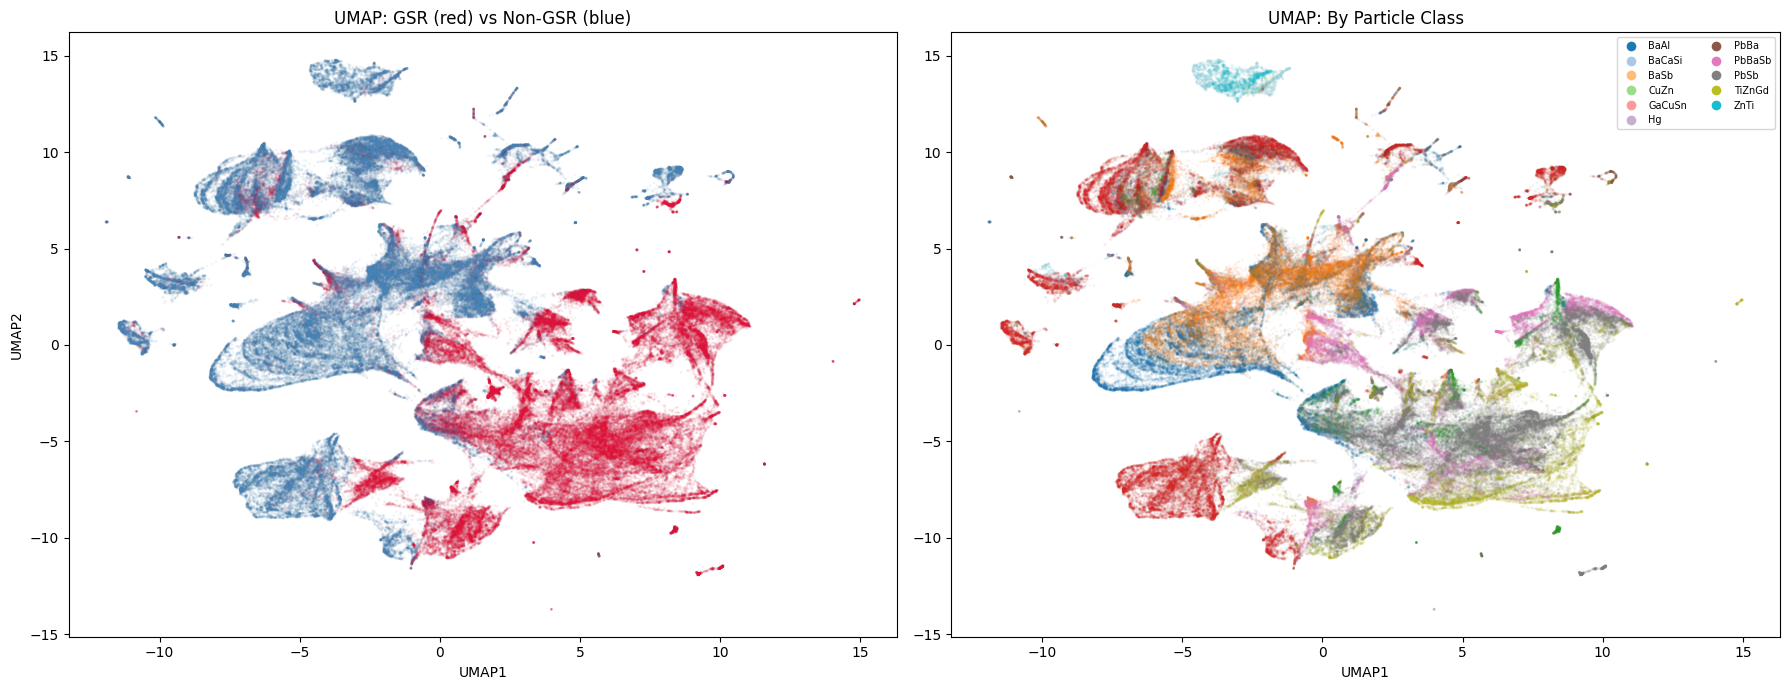

In [8]:
# Plot the UMAP results colored by binary label and particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample['final_class'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

colors = sample['label'].map({'GSR': 'crimson', 'Non_GSR': 'steelblue'}).values
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.05, s=1)
axes[0].set_title('UMAP: GSR (red) vs Non-GSR (blue)')
axes[0].set_xlabel('UMAP1')
axes[0].set_ylabel('UMAP2')

scatter = axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=class_encoded,
                           cmap='tab20', alpha=0.05, s=1)
axes[1].set_title('UMAP: By Particle Class')
axes[1].set_xlabel('UMAP1')

handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab20(i / len(le.classes_)),
           markersize=8, label=cls)
           for i, cls in enumerate(le.classes_)]
axes[1].legend(handles=handles, loc='upper right', fontsize=7,
               ncol=2, markerscale=1)

plt.tight_layout()
plt.show()

In [12]:
# Get ambiguous class
ambiguous = nfi_df[nfi_df['label'] == 'Ambiguous']
ambiguous['final_class'].value_counts()

final_class
Sb    225676
Pb    168334
Ba     89277
Sr     23395
Name: count, dtype: int64

In [14]:
# Sample 10% of ambiguous class
amb_sample, _ = train_test_split(ambiguous, train_size=0.1, random_state=42)

X_amb = scaler.transform(amb_sample[informative_cols].fillna(0).values)
X_amb_umap = reducer.transform(X_amb)

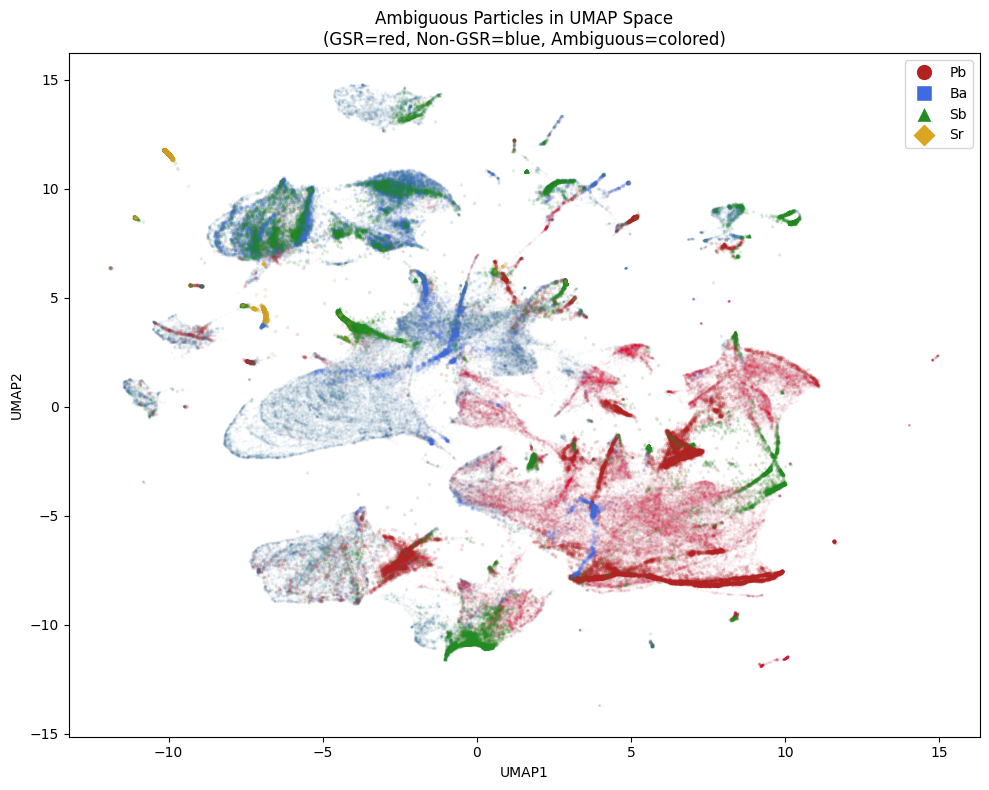

In [16]:
# Overlay ambiguous class
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, alpha=0.02, s=1)

for cls, color, marker in [('Pb', 'firebrick', 'o'), ('Ba', 'royalblue', 's'),
                            ('Sb', 'forestgreen', '^'), ('Sr', 'goldenrod', 'D')]:
    mask = amb_sample['final_class'] == cls
    if mask.sum() > 0:
        ax.scatter(X_amb_umap[mask, 0], X_amb_umap[mask, 1],
                   c=color, s=3, alpha=0.1, label=cls, marker=marker)

# Create custom legend handles with larger markers
handles = [plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=color, markersize=12, label=cls)
           for cls, color, marker in [('Pb', 'firebrick', 'o'), ('Ba', 'royalblue', 's'),
                                      ('Sb', 'forestgreen', '^'), ('Sr', 'goldenrod', 'D')]]
ax.legend(handles=handles, fontsize=10)
ax.set_title('Ambiguous Particles in UMAP Space\n(GSR=red, Non-GSR=blue, Ambiguous=colored)')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.tight_layout()
plt.show()

In [18]:
# Evaluate some metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [25]:
# kNN classification accuracy
# Tests whether neighbors in the embedding share labels
X_umap_np = np.array(X_umap)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample['label'].values)
knn_umap = cross_val_score(knn, X_umap_np, labels, cv=5, scoring='accuracy').mean()

f"kNN classification accuracy: {knn_umap * 100:.1f}%"

'kNN classification accuracy: 94.0%'